### import libraries

In [60]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

import pandas as pd

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

In [ ]:
# ---- presentation-friendly plot defaults: larger fonts + a fixed, colorblind-safe categorical palette ----
from cycler import cycler

# Fixed-order, colorblind-safe categorical palette: assign by identity (config label / E_seed value),
# never by rank, so the same series keeps the same color everywhere it appears in this notebook.
CATEGORICAL_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

# Neutral, low-chroma inks for the two experimental datasets (as opposed to the vivid, high-chroma
# config colors above): distinct from each other, but both deliberately recede next to the first
# four palette colors so the model curves are what pops.
EXPERIMENT_INK_TOP = "#0b0b0b"      # experiment centered ~8020 eV (near-black)
EXPERIMENT_INK_BOTTOM = "#767671"   # experiment centered ~8045 eV (mid warm gray)

E_seed_colors = {2: CATEGORICAL_PALETTE[0], 9: CATEGORICAL_PALETTE[1], 40: CATEGORICAL_PALETTE[2],
                  60: CATEGORICAL_PALETTE[3], 80: CATEGORICAL_PALETTE[4]}

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 20,
    'legend.title_fontsize': 18,
    'figure.titlesize': 26,
    'lines.linewidth': 2.4,
    'axes.prop_cycle': cycler(color=CATEGORICAL_PALETTE),
})

### Transmission

In [62]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

### reading and plotting

In [63]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [64]:
Tshow_min = 0.15#0.4
Tshow_max = 0.5
w_show = 15
w_show_min = -w_show
w_show_max = w_show

[0.40538537 0.40554354 0.40541036 ... 0.40521623 0.40527418 0.40537063]
[0.40596984 0.40607065 0.40600142 ... 0.40592828 0.40595864 0.40599112]
[0.40703746 0.40705744 0.4070413  ... 0.40703462 0.40704336 0.40704763]
[0.4072954  0.40729991 0.40729626 ... 0.40729486 0.4072968  0.40729771]


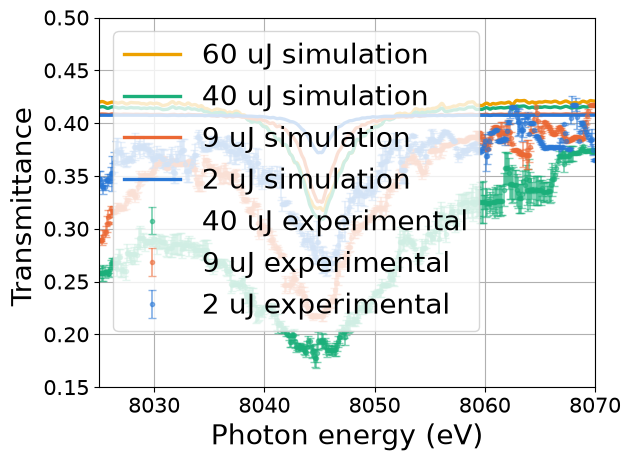

In [65]:
data_path = "../data/production_sweep_sase_24437070/Cu-seed-SASE-no-2s"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[40], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[9], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[2], alpha=0.55)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = E_seed_colors

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar

    print(Tint_w)
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(8025, 8070)
plt.legend()
plt.grid(True)
plt.show()

In [66]:
def estimate_dip(energy, transmittance, center=8045.0, baseline_halfwidth=15.0, dip_halfwidth=8.0,
                  valid_range=(8025, 8070)):
    """Dip depth = (off-resonance baseline transmittance) - (minimum transmittance near center).

    `valid_range` restricts to the plotted window: the raw simulation arrays extend far past it,
    and Tint_w blows up numerically out there (I_int_thy_w_0 -> 0 far from the pulse spectrum).
    """
    energy = np.asarray(energy)
    transmittance = np.asarray(transmittance)
    valid = (energy >= valid_range[0]) & (energy <= valid_range[1])
    energy, transmittance = energy[valid], transmittance[valid]

    baseline_mask = np.abs(energy - center) > baseline_halfwidth
    dip_mask = np.abs(energy - center) <= dip_halfwidth

    baseline = np.mean(transmittance[baseline_mask])
    dip_min = np.min(transmittance[dip_mask])
    depth_abs = baseline - dip_min
    depth_pct = 100 * depth_abs / baseline
    return baseline, dip_min, depth_abs, depth_pct


E_seed_targets = [2, 9, 40]
dip_results = {}

for E_seed_value in E_seed_targets:
    arrays = sorted_accumulated_arrays[E_seed_value]
    Tint_w = arrays['I_int_thy_w_last'] / arrays['I_int_thy_w_0']
    energy_sim = hwKalpha1N + arrays['womega_ar']
    sim_baseline, sim_min, sim_depth, sim_depth_pct = estimate_dip(energy_sim, Tint_w)

    exp_energy = experimental_df["Photon_energy_eV"].values
    exp_T = experimental_df[f"{E_seed_value}uJ_transmittance"].values
    exp_baseline, exp_min, exp_depth, exp_depth_pct = estimate_dip(exp_energy, exp_T)

    dip_results[E_seed_value] = dict(
        sim_baseline=sim_baseline, sim_min=sim_min, sim_depth=sim_depth, sim_depth_pct=sim_depth_pct,
        exp_baseline=exp_baseline, exp_min=exp_min, exp_depth=exp_depth, exp_depth_pct=exp_depth_pct,
    )

print(f"{'E_seed':>8} | {'Sim depth':>10} {'(% of baseline)':>16} | {'Exp depth':>10} {'(% of baseline)':>16} | {'Sim/Exp':>8} {'Sim-Exp diff':>13}")
print("-" * 100)
for E_seed_value in E_seed_targets:
    r = dip_results[E_seed_value]
    ratio = r['sim_depth'] / r['exp_depth']
    rel_diff_pct = 100 * (r['sim_depth'] - r['exp_depth']) / r['exp_depth']
    print(f"{E_seed_value:>5} uJ | {r['sim_depth']:>10.4f} {r['sim_depth_pct']:>15.1f}% | "
          f"{r['exp_depth']:>10.4f} {r['exp_depth_pct']:>15.1f}% | {ratio:>7.2f}x {rel_diff_pct:>+11.1f}%")

print()
print("Dip size relative to the 40 uJ case:")
ref = dip_results[40]
for E_seed_value in E_seed_targets:
    r = dip_results[E_seed_value]
    sim_rel = 100 * r['sim_depth'] / ref['sim_depth']
    exp_rel = 100 * r['exp_depth'] / ref['exp_depth']
    print(f"  {E_seed_value:>5} uJ -> simulation: {sim_rel:6.1f}% of 40 uJ dip, experiment: {exp_rel:6.1f}% of 40 uJ dip")


  E_seed |  Sim depth  (% of baseline) |  Exp depth  (% of baseline) |  Sim/Exp  Sim-Exp diff
----------------------------------------------------------------------------------------------------
    2 uJ |     0.0356             8.7% |     0.1154            30.2% |    0.31x       -69.2%
    9 uJ |     0.0834            20.4% |     0.1514            41.1% |    0.55x       -44.9%
   40 uJ |     0.1060            25.6% |     0.1461            45.2% |    0.73x       -27.4%

Dip size relative to the 40 uJ case:
      2 uJ -> simulation:   33.6% of 40 uJ dip, experiment:   79.0% of 40 uJ dip
      9 uJ -> simulation:   78.7% of 40 uJ dip, experiment:  103.6% of 40 uJ dip
     40 uJ -> simulation:  100.0% of 40 uJ dip, experiment:  100.0% of 40 uJ dip


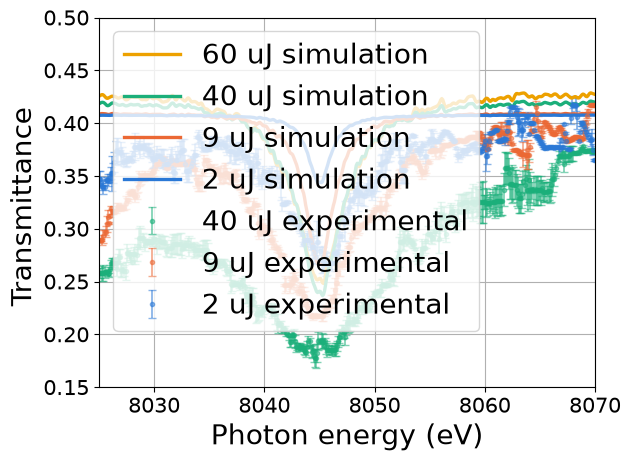

In [67]:
data_path = "../data/production_sweep_sase_24437070/Cu-seed-SASE"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[40], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[9], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[2], alpha=0.55)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = E_seed_colors

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(8025, 8070)
plt.legend()
plt.grid(True)
plt.show()

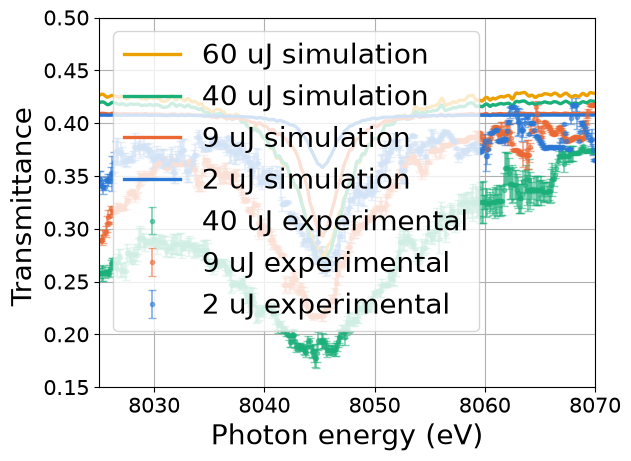

In [68]:
data_path = "../data/production_sweep_sase_24437070/Cu-seed-SASE-satellite-no-L2"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[40], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[9], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[2], alpha=0.55)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = E_seed_colors

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(8025, 8070)
plt.legend()
plt.grid(True)
plt.show()

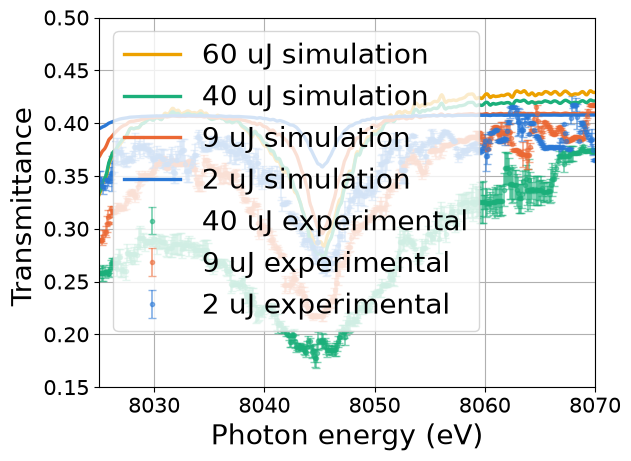

In [69]:
data_path = "../data/production_sweep_sase_24437070/Cu-seed-SASE-satellite"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[40], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[9], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[2], alpha=0.55)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = E_seed_colors

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(8025, 8070)
plt.legend()
plt.grid(True)
plt.show()

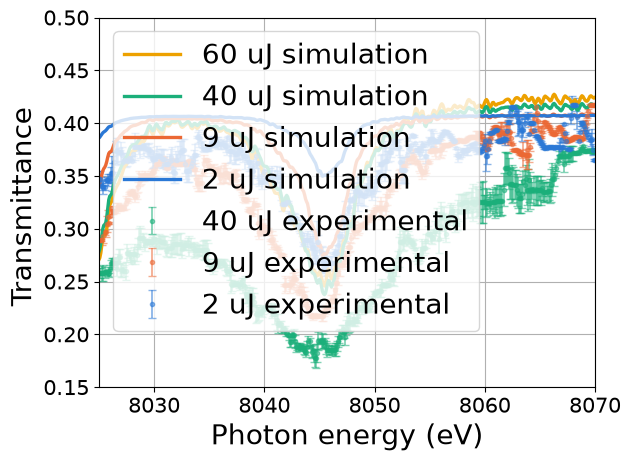

In [70]:
data_path = "../data/production_sweep_sase_24437070/Cu-seed-SASE-double-satellite"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[40], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[9], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[2], alpha=0.55)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = E_seed_colors

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(8025, 8070)
plt.legend()
plt.grid(True)
plt.show()

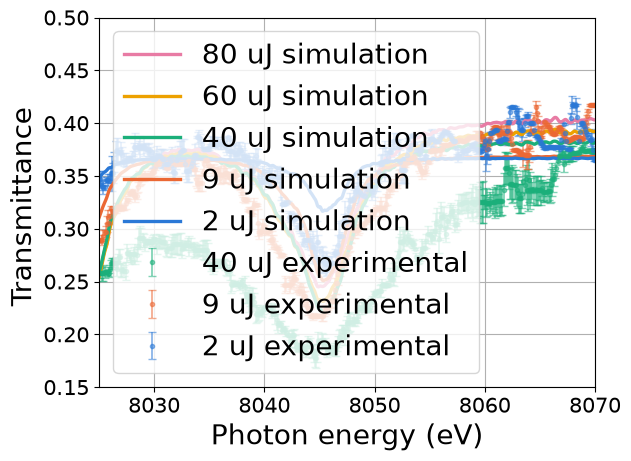

In [71]:
data_path = "../data/sweep_double_satellite_and_L2_update"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys='E_seed_uJ',
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 
              'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, seed_width_FWHM_x, seed_width_FWHM_y = aux_data

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[40], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[9], alpha=0.55)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=3, ms=6, elinewidth=1.3, color=E_seed_colors[2], alpha=0.55)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = E_seed_colors

hwKalpha1N = 8045

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(8025, 8070)
plt.legend()
plt.grid(True)
plt.show()

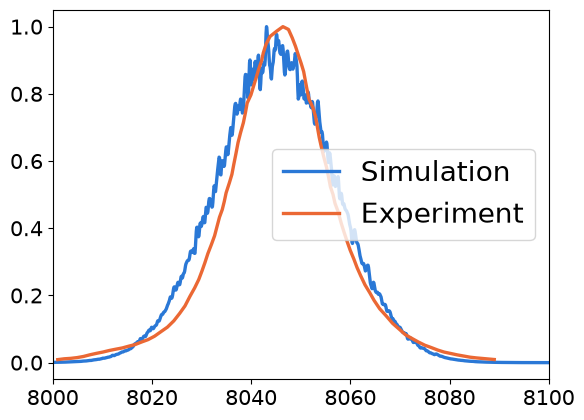

In [72]:
intensity_df = pd.read_csv("../data/intensity_spectra.csv")

I_int_thy_w_0 = sorted_accumulated_arrays[40]['I_int_thy_w_0']
plt.plot(energy_eV, I_int_thy_w_0/I_int_thy_w_0.max(), label="Simulation")
plt.plot(intensity_df["Photon_energy_eV"], intensity_df["Intensity"]/intensity_df["Intensity"].max(), label="Experiment")
plt.xlim(8000, 8100)
plt.legend()
plt.show()

### Side-by-side comparison across configs (2, 9, 40 uJ)

In [ ]:
config_paths = {
    "original": "../data/production_sweep_sase_24437070/Cu-seed-SASE-no-2s",
    # "base (L3 only)": "../data/production_sweep_sase_24437070/Cu-seed-SASE",
    "single-satellite": "../data/production_sweep_sase_24437070/Cu-seed-SASE-satellite-no-L2",
    "single-satellite-L2": "../data/production_sweep_sase_24437070/Cu-seed-SASE-satellite",
    "double-satellite-L2": "../data/production_sweep_sase_24437070/Cu-seed-SASE-double-satellite",
    # "double-satellite-grasp": "../data/production_sweep_sase_24437070/Cu-seed-SASE-double-satellite-grasp",
    # "double-satellite + L2": "../data/sweep_double_satellite_and_L2_update",
    # "double-satellite + L2 + plasma": "../data/sweep_double_satellite_and_L2_and_plasma_mock",
}

config_colors = dict(zip(config_paths.keys(), CATEGORICAL_PALETTE))

hwKalpha1N = 8045
E_seed_targets = [2, 9, 40]

experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")

config_results = {}
for config_label, data_path in config_paths.items():
    sorted_accumulated_arrays, _, _ = tools.data_from_folder(
        data_path, group_keys='E_seed_uJ',
        aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3',
                  'sigma1_Ka1_other', 'seed_duration_FWHM_t', 'seed_width_FWHM_x', 'seed_width_FWHM_y'],
    )
    config_results[config_label] = sorted_accumulated_arrays

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=True)

for ax, E_seed_value in zip(axes, E_seed_targets):
    ax.errorbar(experimental_df["Photon_energy_eV"], experimental_df[f"{E_seed_value}uJ_transmittance"],
                experimental_df[f"{E_seed_value}uJ_error"], fmt='.', capsize=3, ms=6, elinewidth=1.3,
                color=EXPERIMENT_INK_BOTTOM, label="Experiment")

    for config_label, sorted_accumulated_arrays in config_results.items():
        if E_seed_value not in sorted_accumulated_arrays:
            continue
        arrays = sorted_accumulated_arrays[E_seed_value]
        womega_ar = arrays['womega_ar']
        Tint_w = arrays['I_int_thy_w_last'] / arrays['I_int_thy_w_0']
        energy_eV = hwKalpha1N + womega_ar
        ax.plot(energy_eV, Tint_w, color=config_colors[config_label], label=config_label)

    ax.set_title(f"{E_seed_value} uJ")
    ax.set_xlabel('Photon energy (eV)')
    ax.set_ylim(Tshow_min, Tshow_max)
    ax.set_xlim(8000, 8070)
    ax.grid(True)

axes[0].set_ylabel('Transmittance')

handles_by_label = {}
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles_by_label.setdefault(label, handle)
fig.legend(handles_by_label.values(), handles_by_label.keys(), loc='lower center',
           ncol=len(handles_by_label), bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=(0, 0.14, 1, 1))
plt.show()

### Top-panel comparison (pulse centered ~8020 eV)

The configs loaded above were seeded with a pulse centered around 8043 eV (matching the *bottom*-panel/~8045 eV experimental run used above, not this one). Below ~8015-8020 eV the incident spectrum has very little weight, so `Tint_w` gets numerically noisy/unreliable there (same caveat as the `estimate_dip` note earlier) -- treat that low-energy tail with caution; the ~8025-8050 eV overlap is the meaningful part of the comparison.

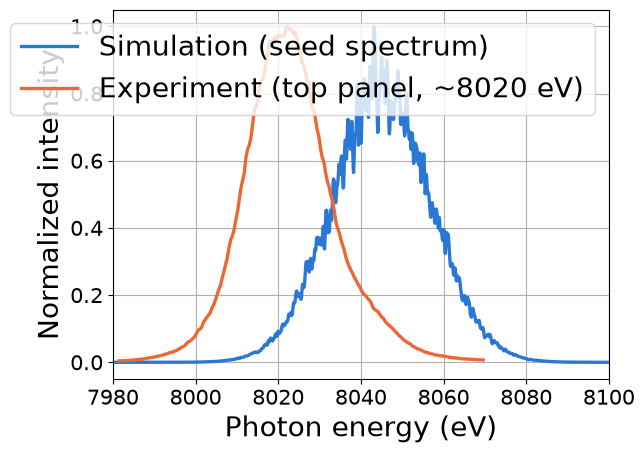

In [74]:
spectrum_top_df = pd.read_csv("../data/intensity_spectrum_top_8020eV.csv")

arrays_ref = config_results["original"][40]
I_int_thy_w_0 = arrays_ref['I_int_thy_w_0']
energy_eV_ref = hwKalpha1N + arrays_ref['womega_ar']

plt.plot(energy_eV_ref, I_int_thy_w_0 / I_int_thy_w_0.max(), label="Simulation (seed spectrum)")
plt.plot(spectrum_top_df["Photon_energy_eV"], spectrum_top_df["Intensity"] / spectrum_top_df["Intensity"].max(),
         label="Experiment (top panel, ~8020 eV)")
plt.xlim(7980, 8100)
plt.xlabel('Photon energy (eV)')
plt.ylabel('Normalized intensity')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
experimental_top_df = pd.read_csv("../data/transmittance_top_all_uJ.csv")
experimental_bottom_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 6.4), sharey=True)

for ax, E_seed_value in zip(axes, E_seed_targets):
    ax.errorbar(experimental_top_df["Photon_energy_eV"], experimental_top_df[f"{E_seed_value}uJ_transmittance"],
                experimental_top_df[f"{E_seed_value}uJ_error"], fmt='v', capsize=3, ms=6, elinewidth=1.3,
                color=EXPERIMENT_INK_TOP, label="Experiment (centered ~8020 eV)")
    ax.errorbar(experimental_bottom_df["Photon_energy_eV"], experimental_bottom_df[f"{E_seed_value}uJ_transmittance"],
                experimental_bottom_df[f"{E_seed_value}uJ_error"], fmt='o', mfc='white', capsize=3, ms=6, elinewidth=1.3,
                color=EXPERIMENT_INK_BOTTOM, label="Experiment (centered ~8045 eV)")

    for config_label, sorted_accumulated_arrays in config_results.items():
        if E_seed_value not in sorted_accumulated_arrays:
            continue
        arrays = sorted_accumulated_arrays[E_seed_value]
        womega_ar = arrays['womega_ar']
        Tint_w = arrays['I_int_thy_w_last'] / arrays['I_int_thy_w_0']
        energy_eV = hwKalpha1N + womega_ar
        ax.plot(energy_eV, Tint_w, color=config_colors[config_label], label=config_label)

    ax.set_title(f"{E_seed_value} uJ")
    ax.set_xlabel('Photon energy (eV)')
    ax.set_ylim(Tshow_min, Tshow_max)
    ax.set_xlim(8000, 8070)
    ax.grid(True)

axes[0].set_ylabel('Transmittance')

handles_by_label = {}
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles_by_label.setdefault(label, handle)
fig.legend(handles_by_label.values(), handles_by_label.keys(), loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=(0, 0.22, 1, 1))
plt.show()

### Progressive step-by-step comparison (with top + bottom experimental data)

Builds the model up config-by-config: each figure highlights the newly-introduced config in full
color while every previously-introduced config stays visible in the same hue at reduced
alpha/linewidth, so it's clear what each addition changes relative to what came before. Both
experimental runs are overlaid on every panel — **top** = pulse centered ~8020 eV
(`transmittance_top_all_uJ.csv`), **bottom** = pulse centered ~8045 eV
(`transmittance_2_9_40uJ.csv`).

In [ ]:
step_order = list(config_paths.keys())

def muted_style(color, alpha=0.35, linewidth=1.8, zorder=2):
    return dict(color=color, alpha=alpha, linewidth=linewidth, zorder=zorder)

highlight_style = dict(linewidth=3.4, zorder=4)

exp_top_style = dict(fmt='v', capsize=3, ms=7, elinewidth=1.4, color=EXPERIMENT_INK_TOP,
                      label="Experiment (centered ~8020 eV)")
exp_bottom_style = dict(fmt='o', mfc='white', capsize=3, ms=7, elinewidth=1.4, color=EXPERIMENT_INK_BOTTOM,
                         label="Experiment (centered ~8045 eV)")

for step_idx, step_label in enumerate(step_order):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

    for ax, E_seed_value in zip(axes, E_seed_targets):
        ax.errorbar(experimental_top_df["Photon_energy_eV"], experimental_top_df[f"{E_seed_value}uJ_transmittance"],
                    experimental_top_df[f"{E_seed_value}uJ_error"], **exp_top_style)
        ax.errorbar(experimental_bottom_df["Photon_energy_eV"], experimental_bottom_df[f"{E_seed_value}uJ_transmittance"],
                    experimental_bottom_df[f"{E_seed_value}uJ_error"], **exp_bottom_style)

        # previously-introduced configs, muted
        for prev_label in step_order[:step_idx]:
            arrays_by_E = config_results[prev_label]
            if E_seed_value not in arrays_by_E:
                continue
            arrays = arrays_by_E[E_seed_value]
            energy_eV = hwKalpha1N + arrays['womega_ar']
            Tint_w = arrays['I_int_thy_w_last'] / arrays['I_int_thy_w_0']
            ax.plot(energy_eV, Tint_w, label=f"{prev_label}",
                    **muted_style(config_colors[prev_label]))

        # this step's config, highlighted
        arrays_by_E = config_results[step_label]
        if E_seed_value in arrays_by_E:
            arrays = arrays_by_E[E_seed_value]
            energy_eV = hwKalpha1N + arrays['womega_ar']
            Tint_w = arrays['I_int_thy_w_last'] / arrays['I_int_thy_w_0']
            ax.plot(energy_eV, Tint_w, color=config_colors[step_label], label=step_label, **highlight_style)

        ax.set_title(f"Pulse energy of {E_seed_value} uJ")
        ax.set_xlabel('Photon energy (eV)')
        ax.set_ylim(Tshow_min, Tshow_max)
        ax.set_xlim(8000, 8070)
        ax.grid(True)

    axes[0].set_ylabel('Transmittance')
    # fig.suptitle(f"Step {step_idx + 1}/{len(step_order)}: {step_label}", fontsize=13, y=1.03)

    handles_by_label = {}
    for ax in axes:
        for handle, label in zip(*ax.get_legend_handles_labels()):
            handles_by_label.setdefault(label, handle)
    fig.legend(handles_by_label.values(), handles_by_label.keys(), loc='lower center',
               ncol=3, bbox_to_anchor=(0.5, 0.0), fontsize=22)

    plt.tight_layout(rect=(0, 0.22, 1, 1))
    plt.show()